<h1>Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.</h1>

<p>Взял датасет с данными о фильмах, вышедших на стриминговом сервисе Netflix.</p>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")
data = pd.read_csv('netflix_titles.csv', sep=",")
data.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
print(f"\nРазмер датасета: {data.shape}")


Размер датасета: (8807, 12)


In [3]:
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100

missing_df = pd.DataFrame({
    'Колонка': missing_values.index,
    'Пропусков': missing_values.values,
    'Процент': missing_percentage.values,
    'Тип_данных': data.dtypes.values
})

print(missing_df.to_string(index=False))

columns_to_drop = missing_df[missing_df['Процент'] > 5]['Колонка'].tolist()

if columns_to_drop:
    data_cleaned = data.drop(columns=columns_to_drop)
else:
    data_cleaned = data.copy()

remaining_missing = data_cleaned.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

data=data_cleaned

target_columns = ['date_added', 'rating', 'duration']

modes = {}
for col in target_columns:
    mode_value = data[col].mode().iloc[0] if not data[col].mode().empty else None
    modes[col] = mode_value
    
    all_modes = data[col].mode()

data_filled = data.copy()

for col in target_columns:
    if col in data_filled.columns:
        missing_before = data_filled[col].isnull().sum()
        mode_value = modes[col]
        
        if mode_value is not None:
            data_filled[col].fillna(mode_value, inplace=True)
            missing_after = data_filled[col].isnull().sum()

data=data_filled

print(data.isnull().sum())

data.shape

     Колонка  Пропусков   Процент Тип_данных
     show_id          0  0.000000     object
        type          0  0.000000     object
       title          0  0.000000     object
    director       2634 29.908028     object
        cast        825  9.367549     object
     country        831  9.435676     object
  date_added         10  0.113546     object
release_year          0  0.000000      int64
      rating          4  0.045418     object
    duration          3  0.034064     object
   listed_in          0  0.000000     object
 description          0  0.000000     object
show_id         0
type            0
title           0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


/tmp/ipykernel_25681/2049603865.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_filled[col].fillna(mode_value, inplace=True)


(8807, 9)

In [7]:
data.head(5)

,show_id,type,title,date_added,release_year,rating,duration,listed_in,description,rating_encoded
0,s1,Movie,Dick Johnson Is Dead,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",0
1,s2,TV Show,Blood & Water,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",1
2,s3,TV Show,Ganglands,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1
3,s4,TV Show,Jailbirds New Orleans,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1
4,s5,TV Show,Kota Factory,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,1


In [5]:
unique_ratings = data['rating'].unique()
rating_mapping = {rating: idx for idx, rating in enumerate(unique_ratings)}

data['rating_encoded'] = data['rating'].map(rating_mapping)

print("Словарь соответствия:")
for rating, code in rating_mapping.items():
    print(f"{rating} -> {code}")

data.head(5)

Словарь соответствия:
PG-13 -> 0
TV-MA -> 1
PG -> 2
TV-14 -> 3
TV-PG -> 4
TV-Y -> 5
TV-Y7 -> 6
R -> 7
TV-G -> 8
G -> 9
NC-17 -> 10
74 min -> 11
84 min -> 12
66 min -> 13
NR -> 14
TV-Y7-FV -> 15
UR -> 16


,show_id,type,title,date_added,release_year,rating,duration,listed_in,description,rating_encoded
0,s1,Movie,Dick Johnson Is Dead,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",0
1,s2,TV Show,Blood & Water,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",1
2,s3,TV Show,Ganglands,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1
3,s4,TV Show,Jailbirds New Orleans,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1
4,s5,TV Show,Kota Factory,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,1


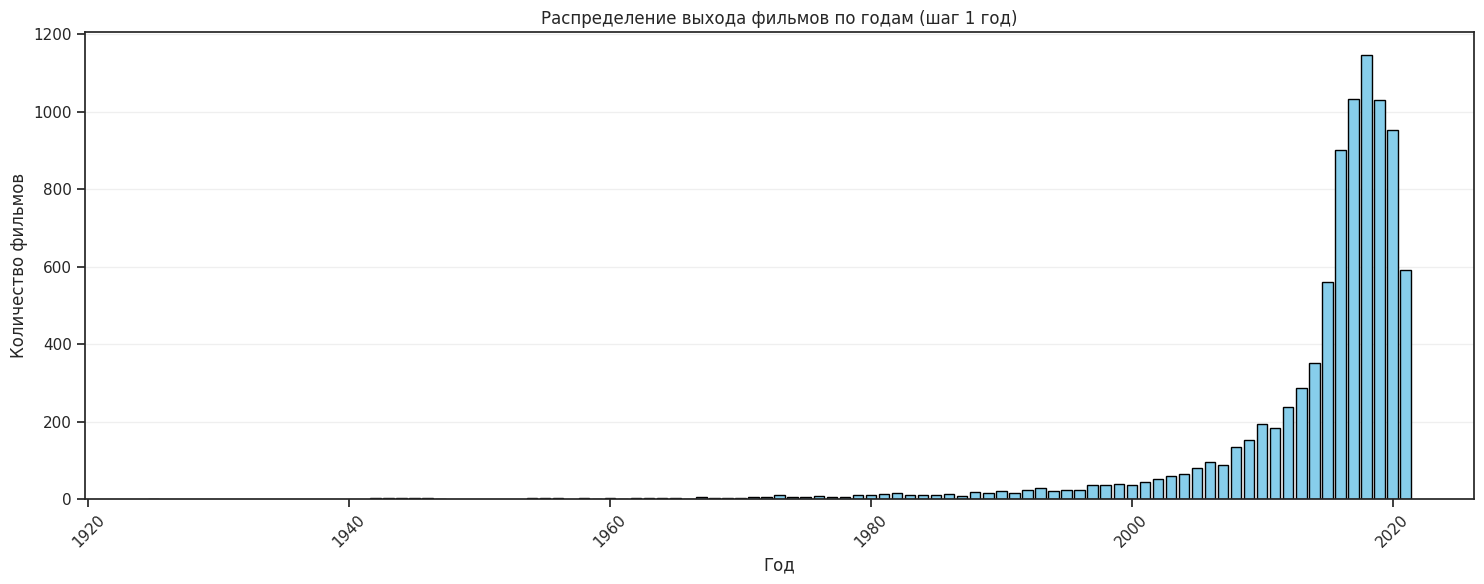

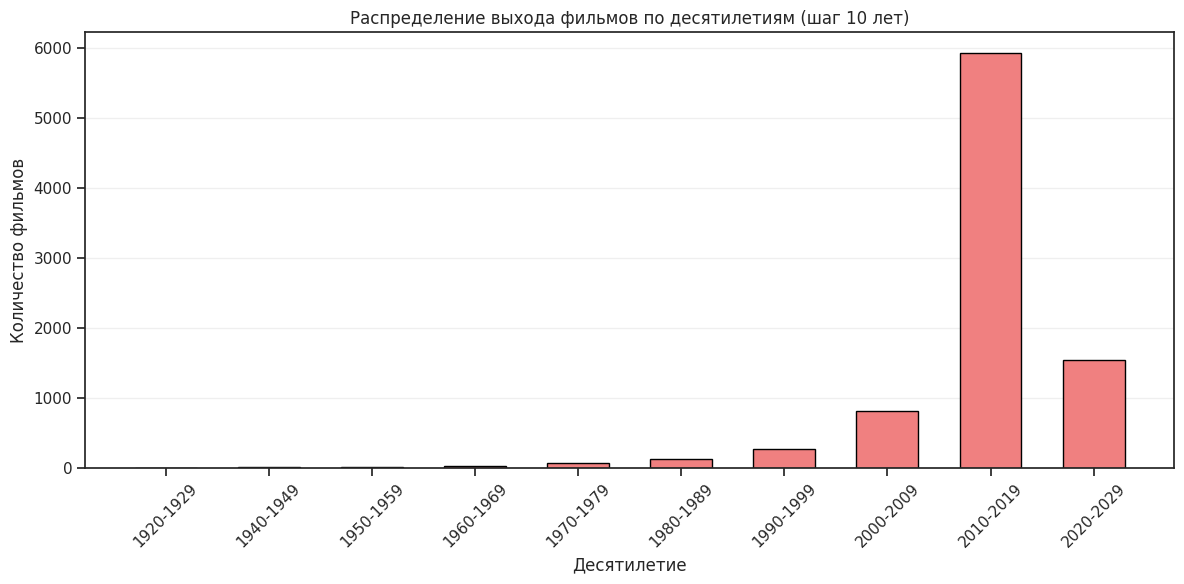

In [6]:
years_data = data['release_year'].dropna()

plt.figure(figsize=(15, 6))
yearly_counts = years_data.value_counts().sort_index()
plt.bar(yearly_counts.index, yearly_counts.values, width=0.8, color='skyblue', edgecolor='black')
plt.xlabel('Год')
plt.ylabel('Количество фильмов')
plt.title('Распределение выхода фильмов по годам (шаг 1 год)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

years_data_int = years_data.astype(int)
decade_labels = []
decade_counts = []

for decade_start in range(int(years_data_int.min() // 10 * 10), int(years_data_int.max()) + 10, 10):
    decade_end = decade_start + 9
    count = ((years_data_int >= decade_start) & (years_data_int <= decade_end)).sum()
    if count > 0:
        decade_labels.append(f"{decade_start}-{decade_end}")
        decade_counts.append(count)

plt.bar(decade_labels, decade_counts, width=0.6, color='lightcoral', edgecolor='black')
plt.xlabel('Десятилетие')
plt.ylabel('Количество фильмов')
plt.title('Распределение выхода фильмов по десятилетиям (шаг 10 лет)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()